# E-Commerce Customer Retention, Revenue & Customer Experience Analysis

**Dataset:** Olist Brazilian E-Commerce  
**Objective:** identify the main drivers of revenue, measure repeat purchasing and retention, segment customers by value and engagement, and quantify the relationship between delivery performance and customer reviews.

## Business questions

1. How much revenue is generated by first purchases vs. returning purchases?
2. How quickly does retention fall after the first purchase?
3. What share of customers make a repeat purchase?
4. Which customer segments contribute the most revenue?
5. Which product categories and regions drive sales?
6. Does late delivery affect review scores?
7. Is revenue growth driven by more customers, higher purchase frequency, or higher order value?

## Reproducibility and methodology note

All analytical tables, metrics, charts, the Excel workbook and the PowerPoint presentation are generated from this notebook.

The first draft was reviewed before publication and two methodology issues were corrected:

- **Cohort retention:** months that are not yet observable are treated as censored (`NaN`) rather than as zero retention.
- **RFM frequency scoring:** one-time buyers are explicitly treated as low-frequency customers instead of receiving a middle score because of tied quantiles.

Workbook styling and presentation layout are also applied programmatically. Analytical values are not manually overwritten after export.

## 1. Environment

Install the dependencies once if needed:

`pip install kagglehub pandas numpy matplotlib xlsxwriter python-pptx`

In [1]:
from pathlib import Path
import warnings

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pptx import Presentation
from pptx.dml.color import RGBColor
from pptx.enum.text import PP_ALIGN, MSO_ANCHOR
from pptx.enum.shapes import MSO_SHAPE
from pptx.util import Inches, Pt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

OUTPUT_DIR = Path("outputs")
CHART_DIR = OUTPUT_DIR / "charts"

OUTPUT_DIR.mkdir(exist_ok=True)
CHART_DIR.mkdir(exist_ok=True)

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load the Olist dataset

In [2]:
dataset_path = Path(
    kagglehub.dataset_download("olistbr/brazilian-ecommerce")
)

files = {
    "customers": "olist_customers_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "items": "olist_order_items_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "translation": "product_category_name_translation.csv",
}

data = {
    name: pd.read_csv(dataset_path / filename)
    for name, filename in files.items()
}

customers = data["customers"]
orders = data["orders"]
items = data["items"]
payments = data["payments"]
reviews = data["reviews"]
products = data["products"]
sellers = data["sellers"]
translation = data["translation"]

print(f"Dataset location: {dataset_path}")
for name, frame in data.items():
    print(f"{name:12s}: {frame.shape[0]:>8,} rows x {frame.shape[1]:>2} columns")

Dataset location: C:\Users\User\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2
customers   :   99,441 rows x  5 columns
orders      :   99,441 rows x  8 columns
items       :  112,650 rows x  7 columns
payments    :  103,886 rows x  5 columns
reviews     :   99,224 rows x  7 columns
products    :   32,951 rows x  9 columns
sellers     :    3,095 rows x  4 columns
translation :       71 rows x  2 columns


## 3. Data quality audit and preparation

In [3]:
audit_rows = []

for name, frame in data.items():
    audit_rows.append({
        "table": name,
        "rows": len(frame),
        "columns": frame.shape[1],
        "duplicate_rows": int(frame.duplicated().sum()),
        "missing_cells": int(frame.isna().sum().sum()),
        "missing_pct": frame.isna().mean().mean(),
    })

audit = pd.DataFrame(audit_rows).sort_values("rows", ascending=False)
audit

,table,rows,columns,duplicate_rows,missing_cells,missing_pct
2,items,112650,7,0,0,0.00
3,payments,103886,5,0,0,0.00
1,orders,99441,8,0,4908,0.01
0,customers,99441,5,0,0,0.00
4,reviews,99224,7,0,145903,0.21
5,products,32951,9,0,2448,0.01
6,sellers,3095,4,0,0,0.00
7,translation,71,2,0,0,0.00


In [4]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

reviews["review_creation_date"] = pd.to_datetime(
    reviews["review_creation_date"], errors="coerce"
)

display(
    orders["order_status"]
    .value_counts(dropna=False)
    .rename_axis("status")
    .to_frame("orders")
)

,orders
status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


### Analysis population

Customer and revenue analysis uses **delivered orders only**.  
Revenue is defined as merchandise value (`price`); freight is tracked separately.  
Customer-level analysis uses `customer_unique_id`, because the same shopper may receive different internal `customer_id` values across purchases.

In [5]:
orders_clean = orders.loc[
    orders["order_status"].eq("delivered")
    & orders["order_purchase_timestamp"].notna()
].copy()

item_agg = (
    items.groupby("order_id", as_index=False)
    .agg(
        merchandise_revenue=("price", "sum"),
        freight_value=("freight_value", "sum"),
        items_count=("order_item_id", "count"),
        sellers_count=("seller_id", "nunique"),
    )
)

payment_agg = (
    payments.groupby("order_id", as_index=False)
    .agg(
        payment_value=("payment_value", "sum"),
        payment_installments=("payment_installments", "max"),
        payment_methods=("payment_type", "nunique"),
    )
)

review_agg = (
    reviews.groupby("order_id", as_index=False)
    .agg(review_score=("review_score", "mean"))
)

order_fact = (
    orders_clean
    .merge(customers, on="customer_id", how="left")
    .merge(item_agg, on="order_id", how="left")
    .merge(payment_agg, on="order_id", how="left")
    .merge(review_agg, on="order_id", how="left")
)

order_fact["merchandise_revenue"] = order_fact["merchandise_revenue"].fillna(0)
order_fact["freight_value"] = order_fact["freight_value"].fillna(0)
order_fact["gross_order_value"] = (
    order_fact["merchandise_revenue"] + order_fact["freight_value"]
)

order_fact["purchase_month"] = (
    order_fact["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

order_fact["delivery_days"] = (
    order_fact["order_delivered_customer_date"]
    - order_fact["order_purchase_timestamp"]
).dt.days

order_fact["delay_days"] = (
    order_fact["order_delivered_customer_date"]
    - order_fact["order_estimated_delivery_date"]
).dt.days

order_fact["late_delivery"] = order_fact["delay_days"].gt(0)

print(f"Delivered orders used in analysis: {len(order_fact):,}")
print(f"Unique customers: {order_fact['customer_unique_id'].nunique():,}")
print(
    "Analysis period:",
    order_fact["order_purchase_timestamp"].min().date(),
    "to",
    order_fact["order_purchase_timestamp"].max().date(),
)

Delivered orders used in analysis: 96,478
Unique customers: 93,358
Analysis period: 2016-09-15 to 2018-08-29


## 4. Executive KPIs

In [6]:
customer_order_counts = (
    order_fact.groupby("customer_unique_id")["order_id"]
    .nunique()
)

unique_customers = customer_order_counts.size
repeat_customers = int((customer_order_counts > 1).sum())
repeat_purchase_rate = repeat_customers / unique_customers

base_kpis = pd.Series({
    "Delivered orders": order_fact["order_id"].nunique(),
    "Unique customers": unique_customers,
    "Merchandise revenue": order_fact["merchandise_revenue"].sum(),
    "Average order value": order_fact["merchandise_revenue"].mean(),
    "Repeat customers": repeat_customers,
    "Repeat purchase rate": repeat_purchase_rate,
    "Average review score": order_fact["review_score"].mean(),
    "Late-delivery rate": order_fact["late_delivery"].mean(),
})

base_kpis.to_frame("value")

,value
Delivered orders,"96,478.00"
Unique customers,"93,358.00"
Merchandise revenue,"13,221,498.11"
Average order value,137.04
Repeat customers,"2,801.00"
Repeat purchase rate,0.03
Average review score,4.16
Late-delivery rate,0.07


## 5. Monthly revenue and customer trends

In [7]:
monthly = (
    order_fact.groupby("purchase_month", as_index=False)
    .agg(
        revenue=("merchandise_revenue", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique"),
    )
)

monthly["avg_order_value"] = monthly["revenue"] / monthly["orders"]
monthly["orders_per_customer"] = monthly["orders"] / monthly["customers"]

monthly.tail()

,purchase_month,revenue,orders,customers,avg_order_value,orders_per_customer
18,2018-04-01,"973,534.09",6798,6744,143.21,1.01
19,2018-05-01,"977,544.69",6749,6693,144.84,1.01
20,2018-06-01,"856,077.86",6099,6061,140.36,1.01
21,2018-07-01,"867,953.46",6159,6100,140.92,1.01
22,2018-08-01,"838,576.64",6351,6310,132.04,1.01


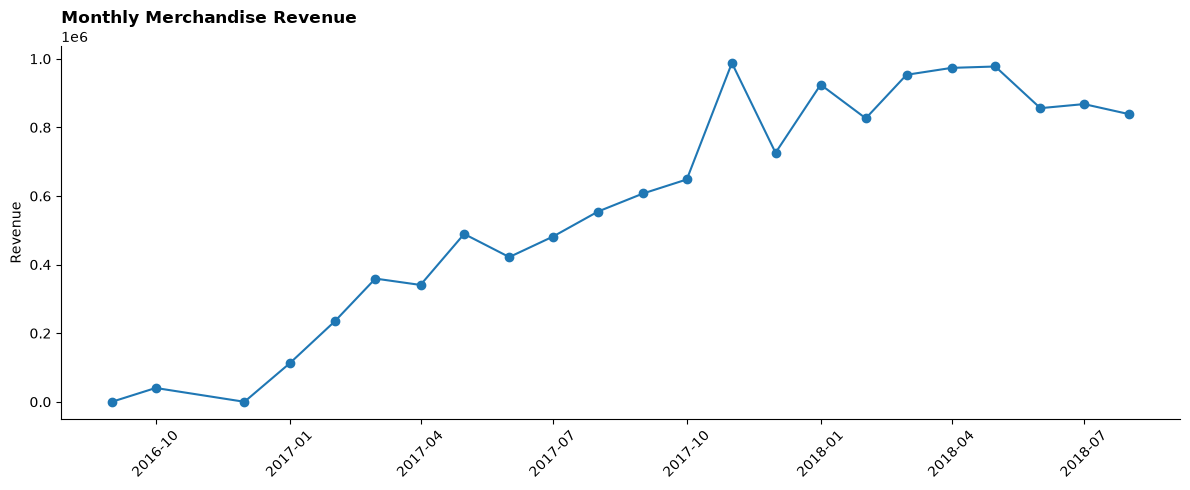

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly["purchase_month"], monthly["revenue"], marker="o")
ax.set_title("Monthly Merchandise Revenue", loc="left", weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Revenue")
ax.tick_params(axis="x", rotation=45)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(CHART_DIR / "01_monthly_revenue.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. New vs. returning customers

In [9]:
order_fact = order_fact.sort_values(
    ["customer_unique_id", "order_purchase_timestamp", "order_id"]
).copy()

order_fact["purchase_number"] = (
    order_fact.groupby("customer_unique_id").cumcount() + 1
)

order_fact["customer_type"] = np.where(
    order_fact["purchase_number"].eq(1),
    "New",
    "Returning",
)

new_returning_monthly = (
    order_fact.groupby(["purchase_month", "customer_type"], as_index=False)
    .agg(
        revenue=("merchandise_revenue", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique"),
    )
)

customer_type_summary = (
    order_fact.groupby("customer_type", as_index=False)
    .agg(
        revenue=("merchandise_revenue", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique"),
    )
)

customer_type_summary["revenue_share"] = (
    customer_type_summary["revenue"]
    / customer_type_summary["revenue"].sum()
)

customer_type_summary

,customer_type,revenue,orders,customers,revenue_share
0,New,"12,838,079.04",93358,93358,0.97
1,Returning,"383,419.07",3120,2801,0.03


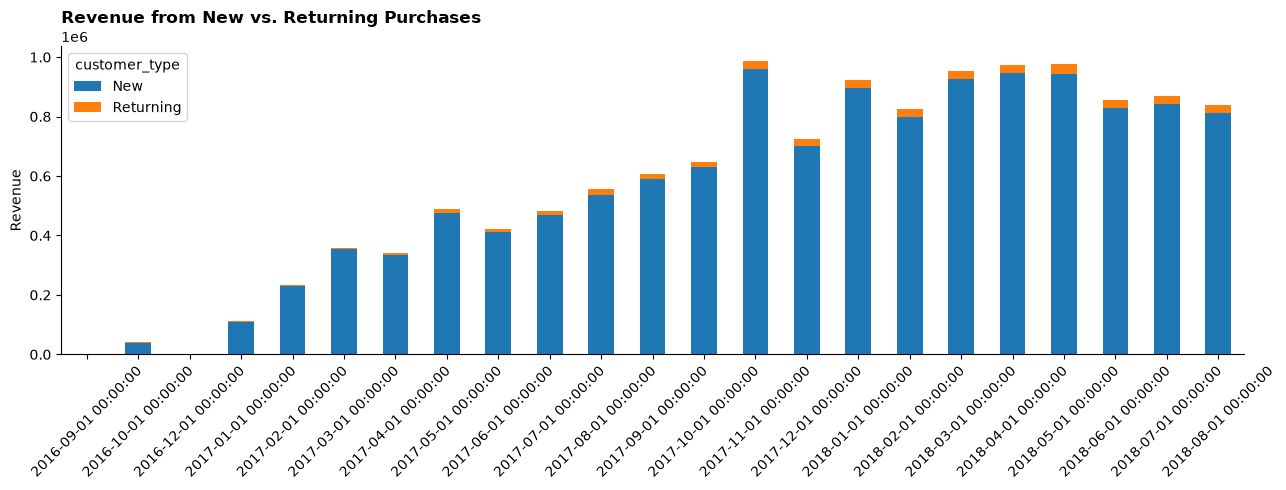

In [10]:
revenue_type = (
    new_returning_monthly
    .pivot(index="purchase_month", columns="customer_type", values="revenue")
    .fillna(0)
)

ax = revenue_type.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 5),
)
ax.set_title("Revenue from New vs. Returning Purchases", loc="left", weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Revenue")
ax.tick_params(axis="x", rotation=45)
ax.spines[["top", "right"]].set_visible(False)
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(CHART_DIR / "02_new_vs_returning_revenue.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. Cohort retention — censored correctly

In [11]:
customer_first_month = (
    order_fact.groupby("customer_unique_id")["purchase_month"]
    .min()
    .rename("cohort_month")
)

cohort_orders = order_fact.merge(
    customer_first_month,
    on="customer_unique_id",
    how="left",
)

cohort_orders["cohort_index"] = (
    (cohort_orders["purchase_month"].dt.year - cohort_orders["cohort_month"].dt.year) * 12
    + (cohort_orders["purchase_month"].dt.month - cohort_orders["cohort_month"].dt.month)
)

cohort_counts = (
    cohort_orders.groupby(["cohort_month", "cohort_index"])["customer_unique_id"]
    .nunique()
    .unstack(fill_value=0)
)

cohort_sizes = cohort_counts.iloc[:, 0]
cohort_retention = cohort_counts.divide(cohort_sizes, axis=0)

# Months outside the observable window are censored, not zero.
last_observed_month = order_fact["purchase_month"].max()

for cohort_month in cohort_retention.index:
    available_months = (
        (last_observed_month.year - cohort_month.year) * 12
        + (last_observed_month.month - cohort_month.month)
    )

    unavailable_columns = [
        col for col in cohort_retention.columns
        if col > available_months
    ]

    if unavailable_columns:
        cohort_retention.loc[cohort_month, unavailable_columns] = np.nan

m1_retention = (
    cohort_retention[1].dropna().mean()
    if 1 in cohort_retention.columns
    else np.nan
)

print(f"Censored-adjusted average M1 retention: {m1_retention:.1%}")
cohort_retention.iloc[:, :13].round(3)

Censored-adjusted average M1 retention: 5.0%


cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2016-09-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2016-10-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2016-12-01,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2017-01-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01
2017-02-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2017-03-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2017-04-01,1.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2017-05-01,1.00,0.01,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2017-06-01,1.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


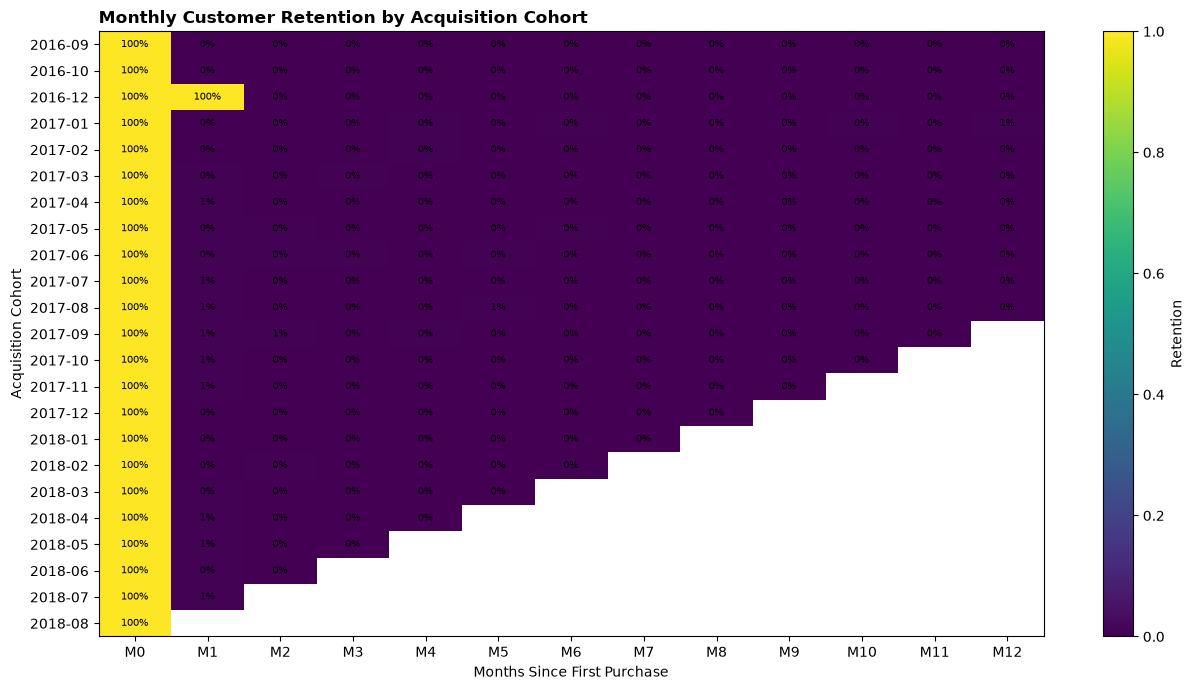

In [12]:
retention_plot = cohort_retention.iloc[:, :13].copy()

fig, ax = plt.subplots(figsize=(13, 7))
img = ax.imshow(
    np.ma.masked_invalid(retention_plot.values.astype(float)),
    aspect="auto",
)

ax.set_title(
    "Monthly Customer Retention by Acquisition Cohort",
    loc="left",
    weight="bold",
)
ax.set_xlabel("Months Since First Purchase")
ax.set_ylabel("Acquisition Cohort")

ax.set_xticks(range(retention_plot.shape[1]))
ax.set_xticklabels([f"M{i}" for i in retention_plot.columns])

y_labels = [x.strftime("%Y-%m") for x in retention_plot.index]
ax.set_yticks(range(len(y_labels)))
ax.set_yticklabels(y_labels)

for i in range(retention_plot.shape[0]):
    for j in range(retention_plot.shape[1]):
        value = retention_plot.iat[i, j]
        if pd.notna(value):
            ax.text(
                j, i, f"{value:.0%}",
                ha="center", va="center", fontsize=7
            )

fig.colorbar(img, ax=ax, label="Retention")
fig.tight_layout()
fig.savefig(CHART_DIR / "03_cohort_retention.png", dpi=180, bbox_inches="tight")
plt.show()

## 8. Repeat purchase behavior

In [13]:
purchase_frequency = (
    order_fact.groupby("customer_unique_id", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("merchandise_revenue", "sum"),
        first_purchase=("order_purchase_timestamp", "min"),
        last_purchase=("order_purchase_timestamp", "max"),
    )
)

repeat_summary = pd.Series({
    "Customers with 1 order": int((purchase_frequency["orders"] == 1).sum()),
    "Customers with 2+ orders": int((purchase_frequency["orders"] >= 2).sum()),
    "Customers with 3+ orders": int((purchase_frequency["orders"] >= 3).sum()),
    "Repeat purchase rate": (purchase_frequency["orders"] >= 2).mean(),
    "Average orders per customer": purchase_frequency["orders"].mean(),
})

repeat_summary.to_frame("value")

,value
Customers with 1 order,"90,557.00"
Customers with 2+ orders,"2,801.00"
Customers with 3+ orders,228.00
Repeat purchase rate,0.03
Average orders per customer,1.03


## 9. RFM segmentation — frequency based on actual repeat behavior

In [14]:
reference_date = (
    order_fact["order_purchase_timestamp"].max().normalize()
    + pd.Timedelta(days=1)
)

rfm = (
    order_fact.groupby("customer_unique_id", as_index=False)
    .agg(
        last_purchase=("order_purchase_timestamp", "max"),
        frequency=("order_id", "nunique"),
        monetary=("merchandise_revenue", "sum"),
    )
)

rfm["recency"] = (
    reference_date - rfm["last_purchase"].dt.normalize()
).dt.days

def percentile_score(series, reverse=False):
    pct_rank = series.rank(method="average", pct=True)
    score = np.ceil(pct_rank * 5).clip(1, 5).astype(int)
    return (6 - score) if reverse else score

rfm["R"] = percentile_score(rfm["recency"], reverse=True)
rfm["M"] = percentile_score(rfm["monetary"])

# Frequency is intentionally based on actual order counts.
# This avoids assigning one-time buyers a middle score because of tied quantiles.
def frequency_score(freq):
    if freq <= 1:
        return 1
    if freq == 2:
        return 3
    return 5

rfm["F"] = rfm["frequency"].apply(frequency_score)

def segment_customer(row):
    r, f, m = int(row["R"]), int(row["F"]), int(row["M"])

    if f >= 3 and r >= 4 and m >= 4:
        return "Champions"
    if f >= 3 and r >= 3:
        return "Loyal Repeat Buyers"
    if f >= 3 and r <= 2:
        return "Repeat Buyers At Risk"
    if f == 1 and r >= 4 and m >= 4:
        return "High-Value New Buyers"
    if f == 1 and r >= 3 and m >= 3:
        return "Promising One-Time Buyers"
    if f == 1 and r <= 2 and m >= 4:
        return "High-Value Dormant Buyers"
    if r <= 2:
        return "Dormant Low-Engagement"
    return "Low-Value One-Time Buyers"

rfm["segment"] = rfm.apply(segment_customer, axis=1)

rfm_summary = (
    rfm.groupby("segment", as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        revenue=("monetary", "sum"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_customer_value=("monetary", "mean"),
    )
    .sort_values("revenue", ascending=False)
)

rfm_summary["customer_share"] = (
    rfm_summary["customers"] / rfm_summary["customers"].sum()
)

rfm_summary["revenue_share"] = (
    rfm_summary["revenue"] / rfm_summary["revenue"].sum()
)

rfm_summary

,segment,customers,revenue,avg_recency,avg_frequency,avg_customer_value,customer_share,revenue_share
3,High-Value New Buyers,14403,"3,857,685.62",92.09,1.00,267.84,0.15,0.29
2,High-Value Dormant Buyers,13708,"3,809,864.25",394.79,1.00,277.93,0.15,0.29
6,Promising One-Time Buyers,17974,"2,704,866.98",168.38,1.00,150.49,0.19,0.20
1,Dormant Low-Engagement,22684,"1,270,251.23",395.64,1.00,56.00,0.24,0.10
4,Low-Value One-Time Buyers,21788,"850,421.28",133.38,1.00,39.03,0.23,0.06
0,Champions,931,"305,122.29",89.27,2.19,327.74,0.01,0.02
7,Repeat Buyers At Risk,997,"248,766.51",381.80,2.08,249.52,0.01,0.02
5,Loyal Repeat Buyers,873,"174,519.95",177.23,2.07,199.91,0.01,0.01


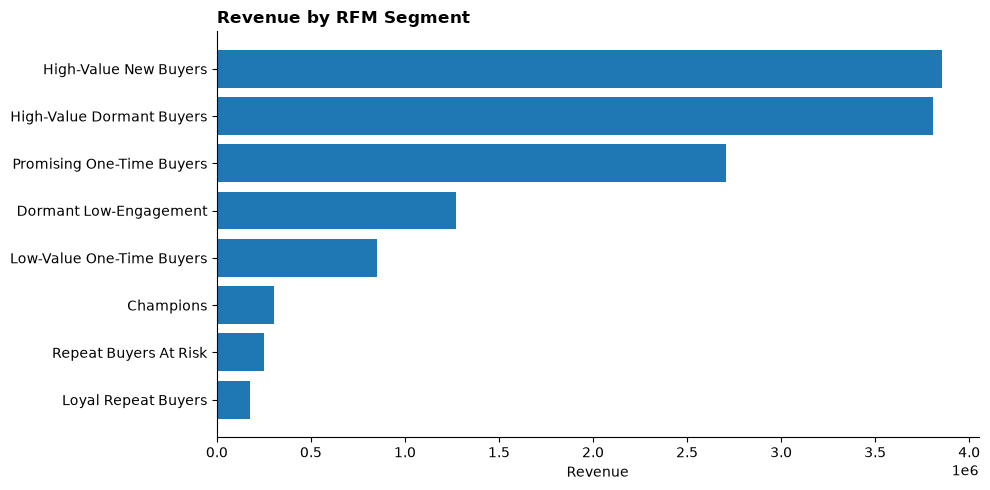

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_data = rfm_summary.sort_values("revenue")
ax.barh(plot_data["segment"], plot_data["revenue"])
ax.set_title("Revenue by RFM Segment", loc="left", weight="bold")
ax.set_xlabel("Revenue")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(CHART_DIR / "04_rfm_revenue.png", dpi=180, bbox_inches="tight")
plt.show()

## 10. Product category performance

In [16]:
products_enriched = products.merge(
    translation,
    on="product_category_name",
    how="left",
)

item_detail = (
    items
    .merge(
        products_enriched[
            [
                "product_id",
                "product_category_name",
                "product_category_name_english",
            ]
        ],
        on="product_id",
        how="left",
    )
    .merge(
        order_fact[
            [
                "order_id",
                "customer_unique_id",
                "purchase_month",
                "review_score",
            ]
        ],
        on="order_id",
        how="inner",
    )
)

item_detail["category"] = (
    item_detail["product_category_name_english"]
    .fillna(item_detail["product_category_name"])
    .fillna("Unknown")
)

category_summary = (
    item_detail.groupby("category", as_index=False)
    .agg(
        revenue=("price", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique"),
        avg_review_score=("review_score", "mean"),
        units=("order_item_id", "count"),
    )
    .sort_values("revenue", ascending=False)
)

category_summary.head(15)

,category,revenue,orders,customers,avg_review_score,units
44,health_beauty,"1,233,131.72",8647,8498,4.19,9465
73,watches_gifts,"1,166,176.98",5495,5421,4.07,5859
8,bed_bath_table,"1,023,434.76",9272,9008,3.92,10953
68,sports_leisure,"954,852.55",7530,7341,4.17,8431
16,computers_accessories,"888,724.61",6530,6405,3.99,7644
40,furniture_decor,"711,927.69",6307,6178,3.95,8160
50,housewares,"615,628.69",5743,5681,4.11,6795
21,cool_stuff,"610,204.10",3559,3543,4.19,3718
6,auto,"578,966.65",3810,3769,4.12,4140
72,toys,"471,286.48",3804,3763,4.21,4030


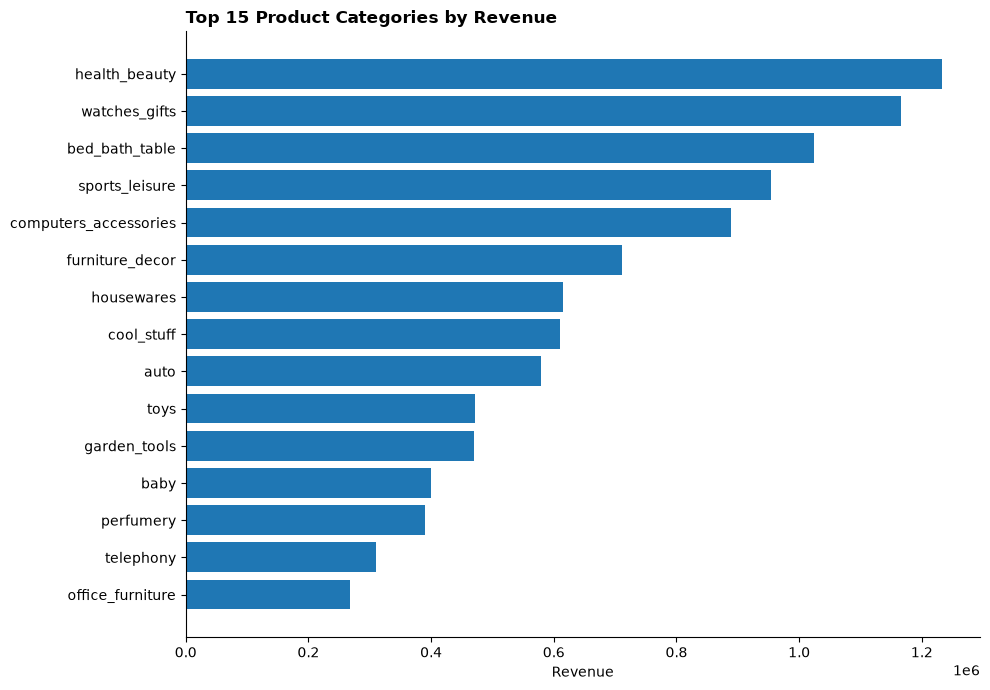

In [17]:
top_categories = category_summary.head(15).sort_values("revenue")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_categories["category"], top_categories["revenue"])
ax.set_title("Top 15 Product Categories by Revenue", loc="left", weight="bold")
ax.set_xlabel("Revenue")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(CHART_DIR / "05_top_categories.png", dpi=180, bbox_inches="tight")
plt.show()

## 11. Geographic performance

In [18]:
state_summary = (
    order_fact.groupby("customer_state", as_index=False)
    .agg(
        revenue=("merchandise_revenue", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique"),
        avg_review_score=("review_score", "mean"),
        late_delivery_rate=("late_delivery", "mean"),
    )
    .sort_values("revenue", ascending=False)
)

state_summary["avg_order_value"] = (
    state_summary["revenue"] / state_summary["orders"]
)

state_summary.head(15)

,customer_state,revenue,orders,customers,avg_review_score,late_delivery_rate,avg_order_value
25,SP,"5,067,633.16",40501,39156,4.25,0.04,125.12
18,RJ,"1,759,651.13",12350,11917,3.97,0.12,142.48
10,MG,"1,552,481.83",11354,11001,4.19,0.05,136.73
22,RS,"728,897.47",5345,5168,4.19,0.06,136.37
17,PR,"666,063.51",4923,4769,4.24,0.04,135.30
23,SC,"507,012.13",3546,3449,4.13,0.08,142.98
4,BA,"493,584.14",3256,3158,3.93,0.12,151.59
6,DF,"296,498.41",2080,2019,4.13,0.06,142.55
8,GO,"282,836.70",1957,1895,4.10,0.07,144.53
7,ES,"268,643.45",1995,1928,4.08,0.11,134.66


## 12. Delivery experience and reviews

In [19]:
delivery_analysis = order_fact.loc[
    order_fact["review_score"].notna()
    & order_fact["order_delivered_customer_date"].notna()
    & order_fact["order_estimated_delivery_date"].notna()
].copy()

delivery_review_summary = (
    delivery_analysis.groupby("late_delivery", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        avg_review_score=("review_score", "mean"),
        median_review_score=("review_score", "median"),
        avg_delivery_days=("delivery_days", "mean"),
        avg_delay_days=("delay_days", "mean"),
    )
)

delivery_review_summary["delivery_status"] = (
    delivery_review_summary["late_delivery"]
    .map({
        False: "On time / early",
        True: "Late",
    })
)

delivery_review_summary

,late_delivery,orders,avg_review_score,median_review_score,avg_delivery_days,avg_delay_days,delivery_status
0,False,89443,4.29,5.00,10.53,-13.51,On time / early
1,True,6381,2.27,1.00,33.36,10.52,Late


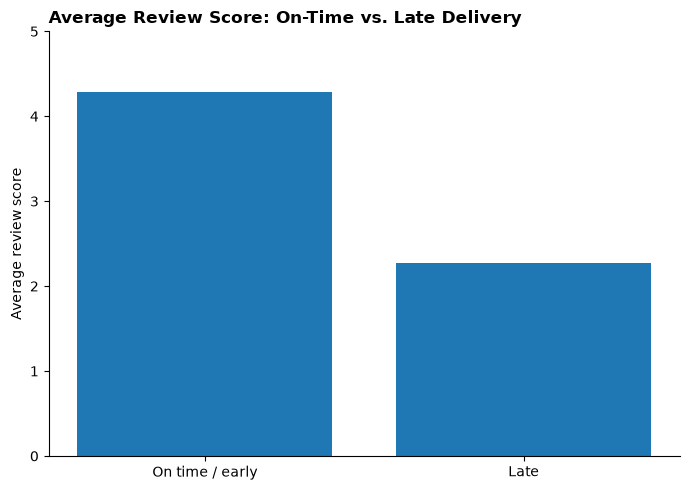

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(
    delivery_review_summary["delivery_status"],
    delivery_review_summary["avg_review_score"],
)
ax.set_title(
    "Average Review Score: On-Time vs. Late Delivery",
    loc="left",
    weight="bold",
)
ax.set_ylabel("Average review score")
ax.set_ylim(0, 5)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(CHART_DIR / "06_delivery_vs_reviews.png", dpi=180, bbox_inches="tight")
plt.show()

## 13. Revenue driver decomposition

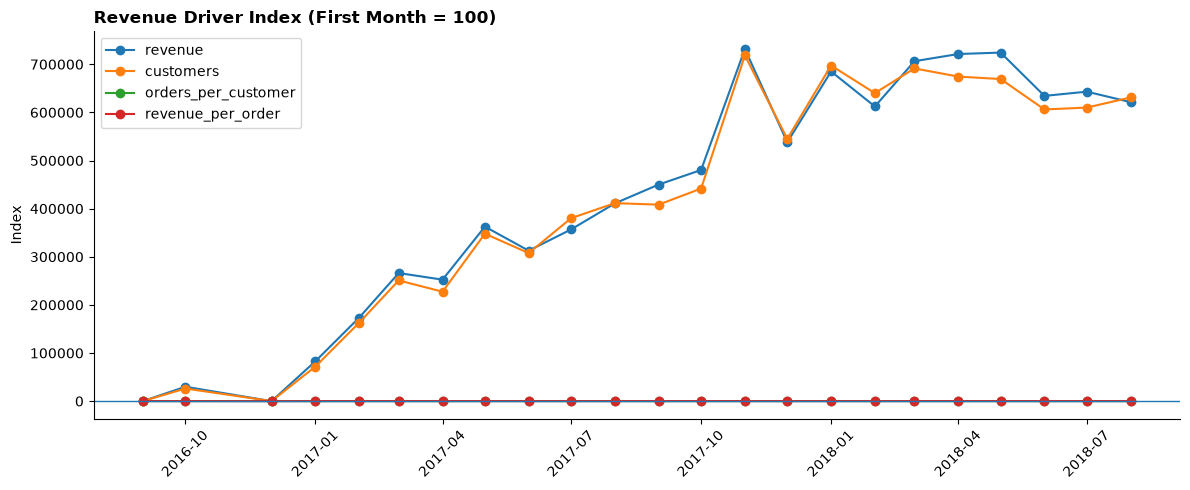

In [21]:
monthly_drivers = (
    order_fact.groupby("purchase_month", as_index=False)
    .agg(
        revenue=("merchandise_revenue", "sum"),
        customers=("customer_unique_id", "nunique"),
        orders=("order_id", "nunique"),
    )
)

monthly_drivers["orders_per_customer"] = (
    monthly_drivers["orders"] / monthly_drivers["customers"]
)

monthly_drivers["revenue_per_order"] = (
    monthly_drivers["revenue"] / monthly_drivers["orders"]
)

monthly_drivers["revenue_check"] = (
    monthly_drivers["customers"]
    * monthly_drivers["orders_per_customer"]
    * monthly_drivers["revenue_per_order"]
)

driver_index = monthly_drivers.copy()

for col in [
    "revenue",
    "customers",
    "orders_per_customer",
    "revenue_per_order",
]:
    first_valid = driver_index[col].replace(0, np.nan).dropna().iloc[0]
    driver_index[col] = driver_index[col] / first_valid * 100

fig, ax = plt.subplots(figsize=(12, 5))

for col in [
    "revenue",
    "customers",
    "orders_per_customer",
    "revenue_per_order",
]:
    ax.plot(
        driver_index["purchase_month"],
        driver_index[col],
        marker="o",
        label=col,
    )

ax.axhline(100, linewidth=1)
ax.set_title("Revenue Driver Index (First Month = 100)", loc="left", weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Index")
ax.legend()
ax.tick_params(axis="x", rotation=45)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(CHART_DIR / "07_revenue_drivers.png", dpi=180, bbox_inches="tight")
plt.show()

## 14. Management findings

In [22]:
new_share = float(
    customer_type_summary.loc[
        customer_type_summary["customer_type"].eq("New"),
        "revenue_share",
    ].iloc[0]
)

returning_share = float(
    customer_type_summary.loc[
        customer_type_summary["customer_type"].eq("Returning"),
        "revenue_share",
    ].iloc[0]
)

late_review = float(
    delivery_review_summary.loc[
        delivery_review_summary["late_delivery"].eq(True),
        "avg_review_score",
    ].iloc[0]
)

ontime_review = float(
    delivery_review_summary.loc[
        delivery_review_summary["late_delivery"].eq(False),
        "avg_review_score",
    ].iloc[0]
)

late_delivery_rate = (
    delivery_analysis["late_delivery"].mean()
)

peak_row = monthly.loc[monthly["revenue"].idxmax()]
peak_month = peak_row["purchase_month"]
peak_revenue = float(peak_row["revenue"])

top_category = category_summary.iloc[0]
top_rfm_segment = rfm_summary.iloc[0]

findings = [
    (
        f"Revenue is acquisition-heavy: first purchases generate "
        f"{new_share:.1%} of merchandise revenue, while returning "
        f"purchases contribute only {returning_share:.1%}."
    ),
    (
        f"Repeat buying is low: {repeat_purchase_rate:.1%} of customers "
        f"made more than one delivered purchase, and censored-adjusted "
        f"M1 retention is {m1_retention:.1%}."
    ),
    (
        f"The highest-revenue month was {peak_month:%B %Y} with "
        f"{peak_revenue:,.0f} in merchandise revenue."
    ),
    (
        f"Average review score falls from {ontime_review:.2f} for "
        f"on-time/early deliveries to {late_review:.2f} for late deliveries."
    ),
    (
        f"{top_category['category']} is the largest product category "
        f"by revenue at {top_category['revenue']:,.0f}."
    ),
]

recommendations = [
    (
        "Prioritize first-to-second-purchase conversion after the initial "
        "order instead of relying only on continued acquisition."
    ),
    (
        "Track M1/M2 cohort retention, repeat purchase rate and returning-"
        "customer revenue share as recurring management KPIs."
    ),
    (
        "Target high-value new buyers and repeat buyers at risk before "
        "running broad reactivation campaigns."
    ),
    (
        "Investigate categories and regions with high acquisition volume "
        "but weak repeat purchasing."
    ),
    (
        "Treat late delivery as a retention risk and trigger proactive "
        "service recovery for delayed orders."
    ),
]

for finding in findings:
    print("•", finding)

print("\nRecommendations")
for recommendation in recommendations:
    print("•", recommendation)

• Revenue is acquisition-heavy: first purchases generate 97.1% of merchandise revenue, while returning purchases contribute only 2.9%.
• Repeat buying is low: 3.0% of customers made more than one delivered purchase, and censored-adjusted M1 retention is 5.0%.
• The highest-revenue month was November 2017 with 987,765 in merchandise revenue.
• Average review score falls from 4.29 for on-time/early deliveries to 2.27 for late deliveries.
• health_beauty is the largest product category by revenue at 1,233,132.

Recommendations
• Prioritize first-to-second-purchase conversion after the initial order instead of relying only on continued acquisition.
• Track M1/M2 cohort retention, repeat purchase rate and returning-customer revenue share as recurring management KPIs.
• Target high-value new buyers and repeat buyers at risk before running broad reactivation campaigns.
• Investigate categories and regions with high acquisition volume but weak repeat purchasing.
• Treat late delivery as a rete

## 15. Export a client-ready Excel workbook

In [23]:
excel_path = OUTPUT_DIR / "ecommerce_customer_retention_analysis.xlsx"

tables = {
    "Data Quality": audit,
    "Monthly Trends": monthly,
    "New vs Returning": customer_type_summary,
    "Cohort Retention": cohort_retention.reset_index(),
    "Purchase Frequency": purchase_frequency,
    "RFM Customers": rfm,
    "RFM Summary": rfm_summary,
    "Categories": category_summary,
    "States": state_summary,
    "Delivery Reviews": delivery_review_summary,
    "Revenue Drivers": monthly_drivers,
}

with pd.ExcelWriter(
    excel_path,
    engine="xlsxwriter",
    datetime_format="yyyy-mm-dd",
) as writer:

    workbook = writer.book

    title_fmt = workbook.add_format({
        "bold": True,
        "font_size": 18,
        "font_color": "#17324D",
    })

    section_fmt = workbook.add_format({
        "bold": True,
        "font_size": 12,
        "font_color": "#17324D",
        "bottom": 1,
        "bottom_color": "#D9E2F3",
    })

    header_fmt = workbook.add_format({
        "bold": True,
        "font_color": "#FFFFFF",
        "bg_color": "#17324D",
        "border": 0,
        "align": "center",
        "valign": "vcenter",
    })

    text_fmt = workbook.add_format({
        "valign": "top",
    })

    wrap_fmt = workbook.add_format({
        "text_wrap": True,
        "valign": "top",
    })

    money_fmt = workbook.add_format({
        "num_format": "#,##0.00",
    })

    integer_fmt = workbook.add_format({
        "num_format": "#,##0",
    })

    percent_fmt = workbook.add_format({
        "num_format": "0.0%",
    })

    decimal_fmt = workbook.add_format({
        "num_format": "0.00",
    })

    date_fmt = workbook.add_format({
        "num_format": "yyyy-mm-dd",
    })

    month_fmt = workbook.add_format({
        "num_format": "yyyy-mm",
    })

    note_fmt = workbook.add_format({
        "font_color": "#5B6573",
        "italic": True,
        "text_wrap": True,
        "valign": "top",
    })

    # Executive summary
    summary = workbook.add_worksheet("Executive Summary")
    writer.sheets["Executive Summary"] = summary
    summary.hide_gridlines(2)
    summary.set_column("A:A", 3)
    summary.set_column("B:B", 34)
    summary.set_column("C:C", 20)
    summary.set_column("D:D", 62)

    summary.write("B2", "E-Commerce Customer Retention & Revenue Analysis", title_fmt)
    summary.write(
        "B4",
        "Portfolio note",
        section_fmt,
    )
    summary.merge_range(
        "B5:D7",
        (
            "All tables and metrics are generated directly from the Python workflow. "
            "Workbook formatting is applied programmatically. During validation, "
            "cohort censoring and RFM frequency scoring were refined after reviewing "
            "the first analysis. No analytical values are manually overwritten."
        ),
        note_fmt,
    )

    summary.write("B9", "Key metrics", section_fmt)

    kpi_rows = [
        ("Merchandise revenue", order_fact["merchandise_revenue"].sum(), "money"),
        ("Unique customers", unique_customers, "integer"),
        ("Repeat purchase rate", repeat_purchase_rate, "percent"),
        ("M1 retention", m1_retention, "percent"),
        ("Returning-purchase revenue share", returning_share, "percent"),
        ("Late-delivery rate", late_delivery_rate, "percent"),
        ("Review score — on-time / early", ontime_review, "decimal"),
        ("Review score — late", late_review, "decimal"),
    ]

    format_map = {
        "money": money_fmt,
        "integer": integer_fmt,
        "percent": percent_fmt,
        "decimal": decimal_fmt,
    }

    row = 10
    for label, value, kind in kpi_rows:
        summary.write(row, 1, label, text_fmt)
        summary.write(row, 2, value, format_map[kind])
        row += 1

    row += 1
    summary.write(row, 1, "Key findings", section_fmt)
    row += 1

    for finding in findings:
        summary.write(row, 1, "•", text_fmt)
        summary.merge_range(row, 2, row, 3, finding, wrap_fmt)
        row += 1

    row += 1
    summary.write(row, 1, "Recommended actions", section_fmt)
    row += 1

    for recommendation in recommendations:
        summary.write(row, 1, "•", text_fmt)
        summary.merge_range(row, 2, row, 3, recommendation, wrap_fmt)
        row += 1

    summary.freeze_panes(8, 1)

    # Analytical sheets
    for sheet_name, frame in tables.items():
        frame.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False,
            startrow=0,
        )

        worksheet = writer.sheets[sheet_name]
        worksheet.freeze_panes(1, 0)
        worksheet.autofilter(0, 0, len(frame), len(frame.columns) - 1)
        worksheet.hide_gridlines(2)

        for col_idx, col_name in enumerate(frame.columns):
            worksheet.write(0, col_idx, col_name, header_fmt)

            sample = frame[col_name].head(1000).astype(str)
            sample_width = sample.map(len).max() if len(sample) else 0
            width = min(max(len(str(col_name)) + 2, sample_width + 2, 11), 32)
            worksheet.set_column(col_idx, col_idx, width)

        for col_idx, col_name in enumerate(frame.columns):
            lower = str(col_name).lower()

            if "revenue" in lower or "value" in lower and "review" not in lower:
                worksheet.set_column(col_idx, col_idx, None, money_fmt)

            if (
                "share" in lower
                or "rate" in lower
                or "retention" in lower
                or "missing_pct" in lower
            ):
                worksheet.set_column(col_idx, col_idx, None, percent_fmt)

            if "date" in lower or "purchase" in lower and "number" not in lower:
                if pd.api.types.is_datetime64_any_dtype(frame[col_name]):
                    worksheet.set_column(col_idx, col_idx, None, date_fmt)

            if col_name == "purchase_month" or col_name == "cohort_month":
                worksheet.set_column(col_idx, col_idx, 12, month_fmt)

        if sheet_name == "Cohort Retention":
            first_metric_col = 1
            last_metric_col = len(frame.columns) - 1
            if last_metric_col >= first_metric_col and len(frame) > 0:
                worksheet.conditional_format(
                    1,
                    first_metric_col,
                    len(frame),
                    last_metric_col,
                    {
                        "type": "3_color_scale",
                        "min_color": "#FCE8E6",
                        "mid_color": "#FFF4CC",
                        "max_color": "#D9EAD3",
                    },
                )

print(f"Saved: {excel_path}")

Saved: outputs\ecommerce_customer_retention_analysis.xlsx


## 16. Create a client-ready PowerPoint presentation

In [24]:
pptx_path = OUTPUT_DIR / "ecommerce_customer_retention_analysis.pptx"

prs = Presentation()
prs.slide_width = Inches(13.333)
prs.slide_height = Inches(7.5)

NAVY = RGBColor(23, 50, 77)
SLATE = RGBColor(74, 85, 99)
LIGHT = RGBColor(244, 247, 250)
BLUE = RGBColor(52, 105, 154)
RED = RGBColor(173, 66, 60)
GREEN = RGBColor(73, 124, 91)
AMBER = RGBColor(178, 126, 39)
WHITE = RGBColor(255, 255, 255)

def add_background(slide):
    shape = slide.shapes.add_shape(
        MSO_SHAPE.RECTANGLE,
        0, 0,
        prs.slide_width,
        prs.slide_height,
    )
    shape.fill.solid()
    shape.fill.fore_color.rgb = WHITE
    shape.line.fill.background()
    slide.shapes._spTree.remove(shape._element)
    slide.shapes._spTree.insert(2, shape._element)

def add_title(slide, title, subtitle=None):
    box = slide.shapes.add_textbox(
        Inches(0.65), Inches(0.35),
        Inches(12.0), Inches(0.65),
    )
    p = box.text_frame.paragraphs[0]
    p.text = title
    p.font.name = "Aptos Display"
    p.font.size = Pt(26)
    p.font.bold = True
    p.font.color.rgb = NAVY

    if subtitle:
        sub = slide.shapes.add_textbox(
            Inches(0.67), Inches(0.98),
            Inches(11.8), Inches(0.4),
        )
        sp = sub.text_frame.paragraphs[0]
        sp.text = subtitle
        sp.font.name = "Aptos"
        sp.font.size = Pt(11)
        sp.font.color.rgb = SLATE

def add_metric(slide, label, value, x, y, w=2.5, accent=BLUE):
    card = slide.shapes.add_shape(
        MSO_SHAPE.ROUNDED_RECTANGLE,
        Inches(x), Inches(y),
        Inches(w), Inches(0.95),
    )
    card.fill.solid()
    card.fill.fore_color.rgb = LIGHT
    card.line.fill.background()

    value_box = slide.shapes.add_textbox(
        Inches(x + 0.18), Inches(y + 0.12),
        Inches(w - 0.36), Inches(0.34),
    )
    vp = value_box.text_frame.paragraphs[0]
    vp.text = value
    vp.font.name = "Aptos"
    vp.font.size = Pt(20)
    vp.font.bold = True
    vp.font.color.rgb = accent

    label_box = slide.shapes.add_textbox(
        Inches(x + 0.18), Inches(y + 0.54),
        Inches(w - 0.36), Inches(0.23),
    )
    lp = label_box.text_frame.paragraphs[0]
    lp.text = label
    lp.font.name = "Aptos"
    lp.font.size = Pt(9)
    lp.font.color.rgb = SLATE

def add_bullets(slide, bullet_items, x, y, w, h, font_size=13):
    box = slide.shapes.add_textbox(
        Inches(x), Inches(y),
        Inches(w), Inches(h),
    )
    tf = box.text_frame
    tf.clear()
    tf.word_wrap = True

    for i, item in enumerate(bullet_items):
        p = tf.paragraphs[0] if i == 0 else tf.add_paragraph()
        p.text = item
        p.font.name = "Aptos"
        p.font.size = Pt(font_size)
        p.font.color.rgb = SLATE
        p.level = 0
        p.text = "• " + item
        p.space_after = Pt(8)

def add_callout(slide, heading, body, x, y, w, h, accent=BLUE):
    card = slide.shapes.add_shape(
        MSO_SHAPE.ROUNDED_RECTANGLE,
        Inches(x), Inches(y),
        Inches(w), Inches(h),
    )
    card.fill.solid()
    card.fill.fore_color.rgb = LIGHT
    card.line.color.rgb = accent

    hbox = slide.shapes.add_textbox(
        Inches(x + 0.18), Inches(y + 0.12),
        Inches(w - 0.36), Inches(0.25),
    )
    hp = hbox.text_frame.paragraphs[0]
    hp.text = heading
    hp.font.name = "Aptos"
    hp.font.size = Pt(11)
    hp.font.bold = True
    hp.font.color.rgb = NAVY

    bbox = slide.shapes.add_textbox(
        Inches(x + 0.18), Inches(y + 0.43),
        Inches(w - 0.36), Inches(h - 0.55),
    )
    bp = bbox.text_frame.paragraphs[0]
    bp.text = body
    bp.font.name = "Aptos"
    bp.font.size = Pt(9.5)
    bp.font.color.rgb = SLATE

def add_image(slide, image_path, x, y, w):
    slide.shapes.add_picture(
        str(image_path),
        Inches(x), Inches(y),
        width=Inches(w),
    )

def add_footer(slide, number):
    foot = slide.shapes.add_textbox(
        Inches(0.65), Inches(7.15),
        Inches(8.0), Inches(0.18),
    )
    p = foot.text_frame.paragraphs[0]
    p.text = "Olist Brazilian E-Commerce public dataset | Portfolio case"
    p.font.name = "Aptos"
    p.font.size = Pt(7)
    p.font.color.rgb = SLATE

    num = slide.shapes.add_textbox(
        Inches(12.2), Inches(7.12),
        Inches(0.45), Inches(0.2),
    )
    np_ = num.text_frame.paragraphs[0]
    np_.text = str(number)
    np_.alignment = PP_ALIGN.RIGHT
    np_.font.name = "Aptos"
    np_.font.size = Pt(7)
    np_.font.color.rgb = SLATE

def money_short(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"
    if value >= 1_000:
        return f"{value / 1_000:.0f}k"
    return f"{value:,.0f}"

# 1 — Title
slide = prs.slides.add_slide(prs.slide_layouts[6])
add_background(slide)

title_box = slide.shapes.add_textbox(
    Inches(0.7), Inches(1.1),
    Inches(7.2), Inches(1.2),
)
p = title_box.text_frame.paragraphs[0]
p.text = "E-Commerce Customer Retention & Revenue Analysis"
p.font.name = "Aptos Display"
p.font.size = Pt(32)
p.font.bold = True
p.font.color.rgb = NAVY

subtitle = slide.shapes.add_textbox(
    Inches(0.72), Inches(2.35),
    Inches(6.5), Inches(0.5),
)
sp = subtitle.text_frame.paragraphs[0]
sp.text = "Customer growth, repeat purchasing, segmentation and customer experience"
sp.font.name = "Aptos"
sp.font.size = Pt(14)
sp.font.color.rgb = SLATE

add_metric(
    slide, "Merchandise revenue",
    money_short(order_fact["merchandise_revenue"].sum()),
    0.75, 3.35, 2.4, BLUE,
)
add_metric(
    slide, "Repeat purchase rate",
    f"{repeat_purchase_rate:.1%}",
    3.45, 3.35, 2.2, RED,
)
add_metric(
    slide, "M1 retention",
    f"{m1_retention:.1%}",
    0.75, 4.55, 2.4, RED,
)
add_metric(
    slide, "Late-delivery rate",
    f"{late_delivery_rate:.1%}",
    3.45, 4.55, 2.2, AMBER,
)

add_image(
    slide,
    CHART_DIR / "03_cohort_retention.png",
    7.55, 1.2, 5.0,
)

add_callout(
    slide,
    "Portfolio focus",
    (
        "End-to-end customer analytics: data quality, revenue diagnostics, "
        "cohort retention, RFM segmentation and operational impact."
    ),
    7.9, 5.25, 4.25, 1.0, BLUE,
)
add_footer(slide, 1)

# 2 — Executive summary
slide = prs.slides.add_slide(prs.slide_layouts[6])
add_background(slide)
add_title(
    slide,
    "Executive Summary",
    (
        "The dataset shows strong acquisition, but weak repeat buying "
        "and measurable operational impact on reviews."
    ),
)

add_metric(slide, "Revenue from first purchases", f"{new_share:.1%}", 0.75, 1.55, 2.45, BLUE)
add_metric(slide, "Returning-purchase revenue", f"{returning_share:.1%}", 3.45, 1.55, 2.45, RED)
add_metric(slide, "Repeat customers", f"{repeat_purchase_rate:.1%}", 6.15, 1.55, 2.1, RED)
add_metric(slide, "Review score when late", f"{ontime_review:.2f} → {late_review:.2f}", 8.55, 1.55, 2.65, AMBER)

add_bullets(
    slide,
    findings[:4],
    0.8, 2.9, 6.0, 3.3,
    font_size=12.5,
)

add_callout(
    slide,
    "Primary business issue",
    (
        "Customer acquisition generates almost all revenue, but very few "
        "customers return. Retention should become a recurring management KPI."
    ),
    7.4, 3.05, 4.7, 1.25, RED,
)

add_callout(
    slide,
    "Management implication",
    (
        "Growth should be separated into active-customer volume, purchase "
        "frequency and average order value rather than assessed from total revenue alone."
    ),
    7.4, 4.65, 4.7, 1.25, GREEN,
)
add_footer(slide, 2)

# 3 — Revenue
slide = prs.slides.add_slide(prs.slide_layouts[6])
add_background(slide)
add_title(
    slide,
    "Revenue Growth Is Primarily Acquisition-Led",
    (
        "The strongest revenue month was driven by customer volume while "
        "purchase frequency remained structurally low."
    ),
)

add_image(slide, CHART_DIR / "01_monthly_revenue.png", 0.7, 1.3, 7.1)
add_image(slide, CHART_DIR / "07_revenue_drivers.png", 0.7, 4.85, 7.1)

add_callout(
    slide,
    "Peak month",
    (
        f"{peak_month:%B %Y} reached {money_short(peak_revenue)} "
        "in merchandise revenue."
    ),
    8.35, 1.55, 3.8, 0.9, BLUE,
)

add_callout(
    slide,
    "Interpretation",
    (
        "Revenue expansion should be separated into active-customer growth, "
        "order frequency and average order value. This prevents acquisition-led "
        "growth from being mistaken for stronger retention."
    ),
    8.35, 2.75, 3.8, 1.45, BLUE,
)

add_callout(
    slide,
    "Management KPI",
    (
        "Track returning-customer revenue share alongside total revenue each month."
    ),
    8.35, 4.55, 3.8, 1.0, GREEN,
)
add_footer(slide, 3)

# 4 — Cohort retention
slide = prs.slides.add_slide(prs.slide_layouts[6])
add_background(slide)
add_title(
    slide,
    "Cohort Retention Drops Immediately After First Purchase",
    (
        "Incomplete cohort months are censored rather than treated as zero retention."
    ),
)

add_image(slide, CHART_DIR / "03_cohort_retention.png", 0.65, 1.3, 7.6)

add_metric(slide, "Censored-adjusted M1 retention", f"{m1_retention:.1%}", 8.55, 1.55, 3.1, RED)
add_metric(slide, "Repeat purchase rate", f"{repeat_purchase_rate:.1%}", 8.55, 2.7, 3.1, RED)

add_callout(
    slide,
    "What this means",
    (
        "Very few acquired customers convert into a second purchase. "
        "This is a retention and activation issue, not only an acquisition issue."
    ),
    8.4, 4.0, 3.65, 1.15, RED,
)

add_callout(
    slide,
    "Action",
    (
        "Build first-to-second-purchase campaigns by category, purchase timing "
        "and customer value."
    ),
    8.4, 5.45, 3.65, 0.95, GREEN,
)
add_footer(slide, 4)

# 5 — Segmentation
slide = prs.slides.add_slide(prs.slide_layouts[6])
add_background(slide)
add_title(
    slide,
    "Customer Segmentation Separates Value from Frequency",
    (
        "Frequency scoring uses actual repeat behavior so one-time buyers are "
        "not automatically treated as mid-frequency customers."
    ),
)

add_image(slide, CHART_DIR / "04_rfm_revenue.png", 0.75, 1.45, 7.0)

add_metric(
    slide,
    "Top revenue segment",
    str(top_rfm_segment["segment"]),
    8.25, 1.65, 3.65, BLUE,
)

add_metric(
    slide,
    "Share of customer revenue",
    f"{top_rfm_segment['revenue_share']:.1%}",
    8.25, 2.85, 3.65, BLUE,
)

add_callout(
    slide,
    "Segmentation logic",
    (
        "One order = low frequency; two orders = mid frequency; "
        "three or more orders = high frequency."
    ),
    8.1, 4.1, 3.95, 1.0, BLUE,
)

add_callout(
    slide,
    "Use case",
    (
        "Prioritize high-value new buyers and repeat buyers at risk before "
        "broad low-value reactivation."
    ),
    8.1, 5.4, 3.95, 1.0, GREEN,
)
add_footer(slide, 5)

# 6 — Product and region
slide = prs.slides.add_slide(prs.slide_layouts[6])
add_background(slide)
add_title(
    slide,
    "Category and Region Performance Identify Where to Prioritize",
    (
        "Revenue concentration and delivery performance vary materially by "
        "product category and geography."
    ),
)

add_image(slide, CHART_DIR / "05_top_categories.png", 0.65, 1.35, 5.75)

top_states = state_summary.head(10).copy()

state_chart_path = CHART_DIR / "08_top_states_revenue.png"
fig, ax = plt.subplots(figsize=(8, 5))
state_plot = top_states.sort_values("revenue")
ax.barh(state_plot["customer_state"], state_plot["revenue"])
ax.set_title("Top States by Revenue", loc="left", weight="bold")
ax.set_xlabel("Revenue")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(state_chart_path, dpi=180, bbox_inches="tight")
plt.close(fig)

add_image(slide, state_chart_path, 6.7, 1.45, 5.6)

add_callout(
    slide,
    "Largest category",
    (
        f"{top_category['category']} leads revenue with "
        f"{money_short(top_category['revenue'])}."
    ),
    0.85, 6.0, 5.25, 0.72, BLUE,
)

top_state_row = state_summary.iloc[0]
add_callout(
    slide,
    "Largest state",
    (
        f"{top_state_row['customer_state']} leads revenue with "
        f"{money_short(top_state_row['revenue'])}; late-delivery rate is "
        f"{top_state_row['late_delivery_rate']:.1%}."
    ),
    6.85, 6.0, 5.25, 0.72, AMBER,
)
add_footer(slide, 6)

# 7 — Delivery
slide = prs.slides.add_slide(prs.slide_layouts[6])
add_background(slide)
add_title(
    slide,
    "Late Delivery Is a Measurable Customer-Experience Risk",
    "Operational delays correlate with a material drop in customer review scores.",
)

add_image(slide, CHART_DIR / "06_delivery_vs_reviews.png", 0.9, 1.55, 5.3)

add_metric(slide, "On-time / early review score", f"{ontime_review:.2f}", 6.9, 1.7, 2.45, GREEN)
add_metric(slide, "Late-delivery review score", f"{late_review:.2f}", 9.65, 1.7, 2.45, RED)
add_metric(slide, "Late-delivery rate", f"{late_delivery_rate:.1%}", 6.9, 2.95, 2.45, AMBER)

add_bullets(
    slide,
    [
        "Late orders should trigger proactive service recovery before the review is submitted.",
        "Regions with high revenue and high delay rates deserve separate operational review.",
        "Delivery reliability should be tracked as a retention lever, not only as a logistics metric.",
    ],
    6.9, 4.1, 5.15, 2.1,
    font_size=12.5,
)
add_footer(slide, 7)

# 8 — Recommendations
slide = prs.slides.add_slide(prs.slide_layouts[6])
add_background(slide)
add_title(
    slide,
    "Recommended Management Actions",
    (
        "The next step is a repeatable retention reporting process rather than "
        "another one-off analysis."
    ),
)

for i, recommendation in enumerate(recommendations, start=1):
    y = 1.45 + (i - 1) * 0.95

    nbox = slide.shapes.add_textbox(
        Inches(0.85), Inches(y),
        Inches(0.45), Inches(0.35),
    )
    np_ = nbox.text_frame.paragraphs[0]
    np_.text = f"{i:02d}"
    np_.font.name = "Aptos"
    np_.font.size = Pt(12)
    np_.font.bold = True
    np_.font.color.rgb = BLUE

    tbox = slide.shapes.add_textbox(
        Inches(1.45), Inches(y - 0.02),
        Inches(7.2), Inches(0.55),
    )
    tp = tbox.text_frame.paragraphs[0]
    tp.text = recommendation
    tp.font.name = "Aptos"
    tp.font.size = Pt(13)
    tp.font.color.rgb = SLATE

add_callout(
    slide,
    "Suggested recurring dashboard",
    (
        "Monthly revenue, active customers, repeat purchase rate, M1/M2 retention, "
        "returning-customer revenue share, RFM segment revenue and delivery/review impact."
    ),
    9.05, 1.55, 3.25, 1.5, BLUE,
)

add_callout(
    slide,
    "Portfolio deliverables",
    (
        "Jupyter notebook, Excel management workbook, reusable analysis pipeline "
        "and client-ready presentation."
    ),
    9.05, 3.55, 3.25, 1.1, BLUE,
)

add_callout(
    slide,
    "Business value",
    (
        "Transaction data is translated into decisions about acquisition quality, "
        "retention priorities and operational risk."
    ),
    9.05, 5.15, 3.25, 1.1, GREEN,
)
add_footer(slide, 8)

prs.save(pptx_path)
print(f"Saved: {pptx_path}")

Saved: outputs\ecommerce_customer_retention_analysis.pptx


## 17. Deliverables

Running the notebook from top to bottom creates:

- `outputs/ecommerce_customer_retention_analysis.xlsx`
- `outputs/ecommerce_customer_retention_analysis.pptx`
- presentation-ready charts in `outputs/charts/`

The notebook is the reproducible technical artifact.  
The Excel workbook is the management reporting deliverable.  
The PowerPoint presentation is the client-facing summary.